In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('weather.csv')
df.head()

,Data.Precipitation,Date.Full,Date.Month,Date.Week of,Date.Year,Station.City,Station.Code,Station.Location,Station.State,Data.Temperature.Avg Temp,Data.Temperature.Max Temp,Data.Temperature.Min Temp,Data.Wind.Direction,Data.Wind.Speed
0,0.00,2016-01-03,1,3,2016,Birmingham,BHM,"Birmingham, AL",Alabama,39,46,32,33,4.33
1,0.00,2016-01-03,1,3,2016,Huntsville,HSV,"Huntsville, AL",Alabama,39,47,31,32,3.86
2,0.16,2016-01-03,1,3,2016,Mobile,MOB,"Mobile, AL",Alabama,46,51,41,35,9.73
3,0.00,2016-01-03,1,3,2016,Montgomery,MGM,"Montgomery, AL",Alabama,45,52,38,32,6.86
4,0.01,2016-01-03,1,3,2016,Anchorage,ANC,"Anchorage, AK",Alaska,34,38,29,19,7.80


# Data cleaning:

In [4]:
df.duplicated().any()

False

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16743 entries, 0 to 16742
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Data.Precipitation         16743 non-null  float64
 1   Date.Full                  16743 non-null  object 
 2   Date.Month                 16743 non-null  int64  
 3   Date.Week of               16743 non-null  int64  
 4   Date.Year                  16743 non-null  int64  
 5   Station.City               16743 non-null  object 
 6   Station.Code               16743 non-null  object 
 7   Station.Location           16743 non-null  object 
 8   Station.State              16743 non-null  object 
 9   Data.Temperature.Avg Temp  16743 non-null  int64  
 10  Data.Temperature.Max Temp  16743 non-null  int64  
 11  Data.Temperature.Min Temp  16743 non-null  int64  
 12  Data.Wind.Direction        16743 non-null  int64  
 13  Data.Wind.Speed            16743 non-null  flo

In [6]:
df.isnull().sum()

Data.Precipitation           0
Date.Full                    0
Date.Month                   0
Date.Week of                 0
Date.Year                    0
Station.City                 0
Station.Code                 0
Station.Location             0
Station.State                0
Data.Temperature.Avg Temp    0
Data.Temperature.Max Temp    0
Data.Temperature.Min Temp    0
Data.Wind.Direction          0
Data.Wind.Speed              0
dtype: int64

# DATA TRANSFORMATION / MANIPULATION

In [7]:
df.columns

Index(['Data.Precipitation', 'Date.Full', 'Date.Month', 'Date.Week of',
       'Date.Year', 'Station.City', 'Station.Code', 'Station.Location',
       'Station.State', 'Data.Temperature.Avg Temp',
       'Data.Temperature.Max Temp', 'Data.Temperature.Min Temp',
       'Data.Wind.Direction', 'Data.Wind.Speed'],
      dtype='object')

In [8]:
df.columns = df.columns.str.strip().str.title().str.replace(".", "_")

In [9]:
df.columns

Index(['Data_Precipitation', 'Date_Full', 'Date_Month', 'Date_Week Of',
       'Date_Year', 'Station_City', 'Station_Code', 'Station_Location',
       'Station_State', 'Data_Temperature_Avg Temp',
       'Data_Temperature_Max Temp', 'Data_Temperature_Min Temp',
       'Data_Wind_Direction', 'Data_Wind_Speed'],
      dtype='object')

In [10]:
df.columns=['Data_Precipitation','Date','Month','Week','Year','Station_City','Station_Code',
            'Station_Location','Station_State','Average_Temp','Max_Temp','Min_Temp','Wind_Direction','Wind_Speed']

In [11]:
df.columns

Index(['Data_Precipitation', 'Date', 'Month', 'Week', 'Year', 'Station_City',
       'Station_Code', 'Station_Location', 'Station_State', 'Average_Temp',
       'Max_Temp', 'Min_Temp', 'Wind_Direction', 'Wind_Speed'],
      dtype='object')

In [12]:
df['Date']=pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16743 entries, 0 to 16742
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Data_Precipitation  16743 non-null  float64       
 1   Date                16743 non-null  datetime64[ns]
 2   Month               16743 non-null  int32         
 3   Week                16743 non-null  int64         
 4   Year                16743 non-null  int32         
 5   Station_City        16743 non-null  object        
 6   Station_Code        16743 non-null  object        
 7   Station_Location    16743 non-null  object        
 8   Station_State       16743 non-null  object        
 9   Average_Temp        16743 non-null  int64         
 10  Max_Temp            16743 non-null  int64         
 11  Min_Temp            16743 non-null  int64         
 12  Wind_Direction      16743 non-null  int64         
 13  Wind_Speed          16743 non-null  float64   

In [13]:
df.head()

,Data_Precipitation,Date,Month,Week,Year,Station_City,Station_Code,Station_Location,Station_State,Average_Temp,Max_Temp,Min_Temp,Wind_Direction,Wind_Speed
0,0.00,2016-01-03,1,3,2016,Birmingham,BHM,"Birmingham, AL",Alabama,39,46,32,33,4.33
1,0.00,2016-01-03,1,3,2016,Huntsville,HSV,"Huntsville, AL",Alabama,39,47,31,32,3.86
2,0.16,2016-01-03,1,3,2016,Mobile,MOB,"Mobile, AL",Alabama,46,51,41,35,9.73
3,0.00,2016-01-03,1,3,2016,Montgomery,MGM,"Montgomery, AL",Alabama,45,52,38,32,6.86
4,0.01,2016-01-03,1,3,2016,Anchorage,ANC,"Anchorage, AK",Alaska,34,38,29,19,7.80


In [14]:
df.describe()

,Data_Precipitation,Date,Month,Week,Year,Average_Temp,Max_Temp,Min_Temp,Wind_Direction,Wind_Speed
count,16743.000000,16743,16743.000000,16743.000000,16743.000000,16743.000000,16743.000000,16743.000000,16743.000000,16743.000000
mean,0.579090,2016-07-03 02:53:23.296900096,6.343128,15.650242,2016.018933,56.089112,66.042406,45.642716,18.791316,6.329820
min,0.000000,2016-01-03 00:00:00,1.000000,1.000000,2016.000000,-27.000000,-19.000000,-35.000000,0.000000,0.000000
25%,0.000000,2016-04-03 00:00:00,3.000000,8.000000,2016.000000,44.000000,53.000000,33.000000,15.000000,4.040000
50%,0.190000,2016-07-03 00:00:00,6.000000,16.000000,2016.000000,58.000000,68.000000,47.000000,19.000000,5.940000
75%,0.750000,2016-10-02 00:00:00,9.000000,24.000000,2016.000000,71.000000,82.000000,60.000000,23.000000,8.080000
max,20.890000,2017-01-01 00:00:00,12.000000,31.000000,2017.000000,100.000000,111.000000,88.000000,36.000000,61.100000
std,0.988057,NaN,3.490723,8.923425,0.136294,18.798295,19.787954,18.559263,6.461527,3.494785


# Plot  

Histogram (Temperature, Precipitation)

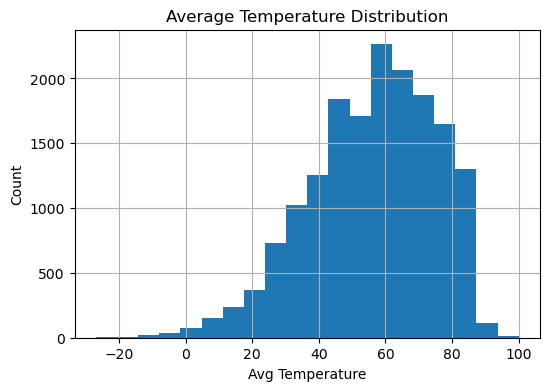

In [31]:
df['Average_Temp'].hist(figsize=(6,4), bins=20)
plt.title("Average Temperature Distribution")
plt.xlabel("Avg Temperature")
plt.ylabel("Count")
plt.show()

# observations:

1. Most of the temperatures fall between 40°C and 70°C, meaning this is the common temperature range in the dataset.
2. Very low temperatures (below 0°C) and very high temperatures (above 90°C) are rare and occur only a few times.
3. There is a gradual increase in frequency from low to mid-range temperatures, and then it decreases after around 60–70°C, showing a natural spread of temperature data.

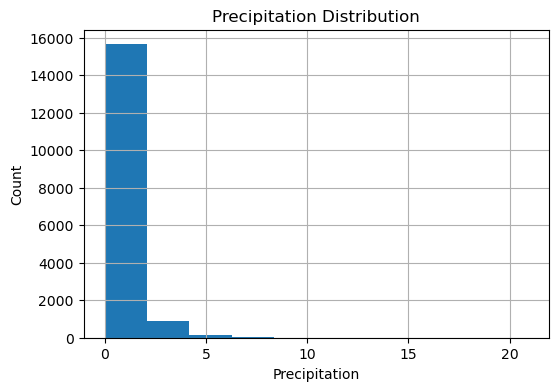

In [29]:
df['Data_Precipitation'].hist(figsize=(6,4))
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation")
plt.ylabel("Count")
plt.show()


# observations:

1. Most precipitation values are close to 0, meaning the majority of days have little to no rainfall.
2. There is a high frequency of very low precipitation values (0–1 mm), showing that light rain or dry days are very common.
3. Heavy rainfall events (above 10 mm) are rare and occur only a few times in the entire dataset.

# Boxplot (Check Outliers)

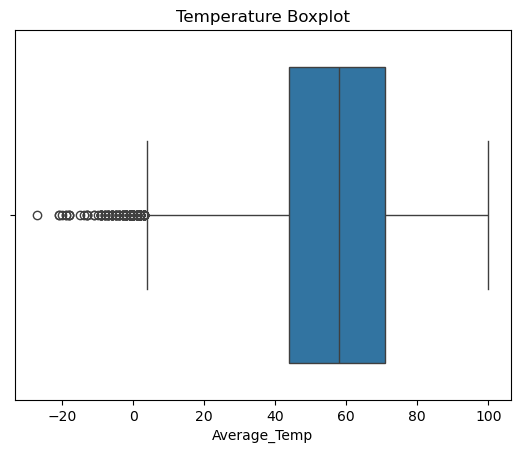

In [17]:
sns.boxplot(x=df['Average_Temp'])
plt.title("Temperature Boxplot")
plt.show()

# observations:

1. Most average temperature values lie between ~45°C and ~75°C, which represents the main average temperature range.
2. The lower whisker extends far left because of these extreme outliers, while the upper whisker is shorter, suggesting the dataset is slightly left-skewed (more low-value extremes).
3. The presence of many cold outliers suggests possible rare weather events or data recording issues.

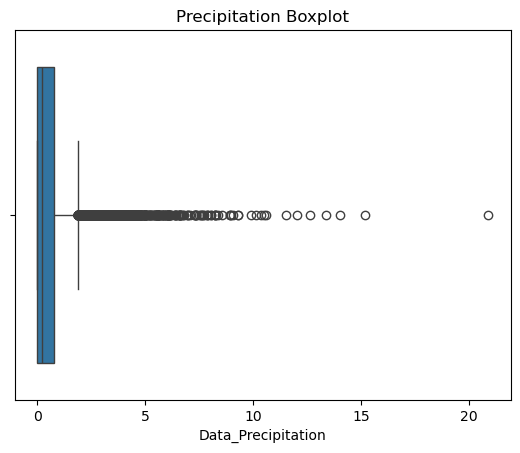

In [18]:
sns.boxplot(x=df['Data_Precipitation'])
plt.title("Precipitation Boxplot")
plt.show()


# observations:

1. Most days had little or no rain, with the IQR concentrated around 0–1 mm.
2. Several outliers show occasional heavy rainfall, indicating rare but significant rain events.
3. The distribution is right-skewed, with a long tail toward higher rainfall and a few extreme values.

# Line Plot (Trend Over Time)

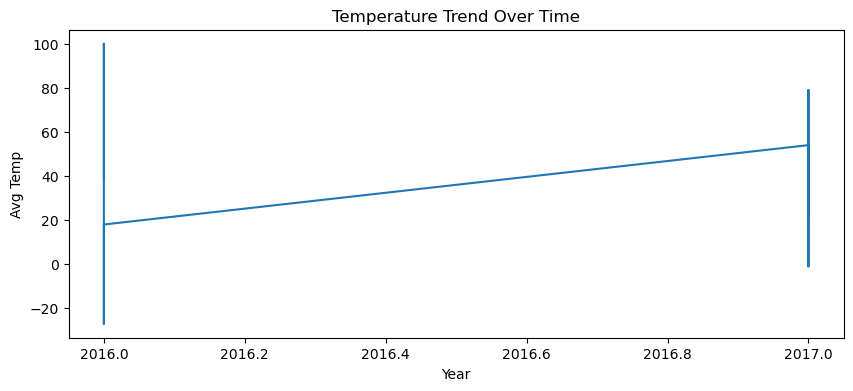

In [19]:
plt.figure(figsize=(10,4))
plt.plot(df['Year'], df['Average_Temp'])
plt.title("Temperature Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Avg Temp")
plt.show()

# observations:

1. No clear increasing or decreasing trend is visible, suggesting temperature is regular over the year.

# Weekly Average Temperature

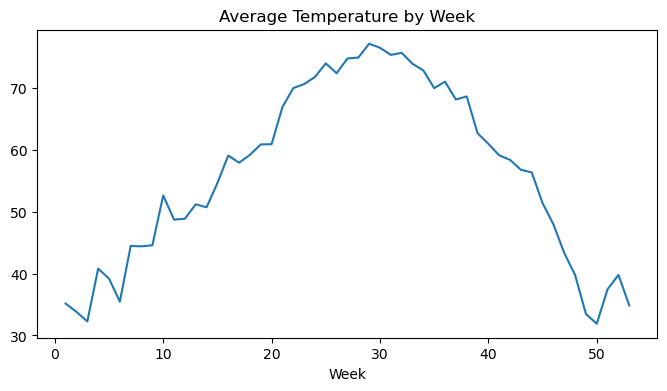

In [21]:
df['Week'] = df['Date'].dt.isocalendar().week
df.groupby('Week')['Average_Temp'].mean().plot(figsize=(8,4))
plt.title("Average Temperature by Week")
plt.show()

# observation

1. The average weekly temperature i s aroung the range of 25-35 deg.
2. it shows the temperature is normal over the weeks.

# KDE Plot — Smooth Distribution

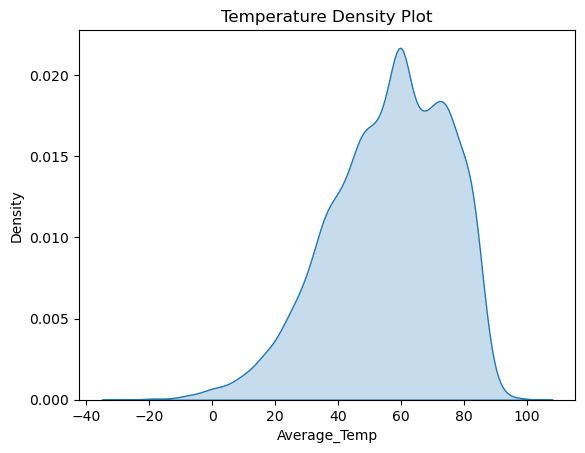

In [22]:
sns.kdeplot(df['Average_Temp'], fill=True)
plt.title("Temperature Density Plot")
plt.show()

# Correlation Heatmap

In [23]:
numeric_cols = ['Data_Precipitation','Month','Week','Year',
                'Average_Temp','Max_Temp','Min_Temp','Wind_Speed']

numeric_df = df[numeric_cols]

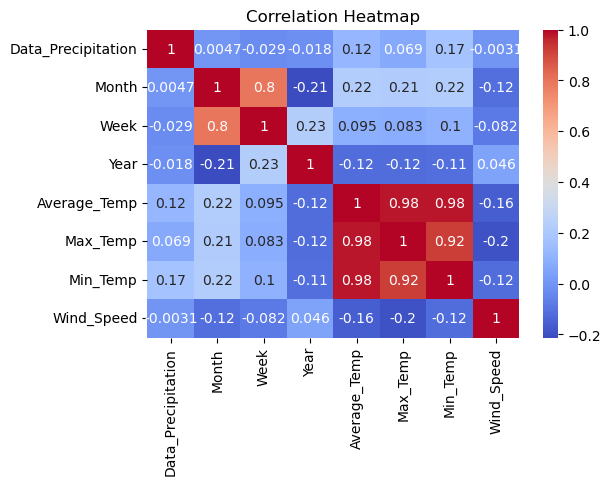

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# conclusion

1. The Average Temperature as been around 45-65.
2. Most of the days as little or less precipitation and there are heavy rainfall occansionally.
3. From monthly and weekly average temperature we can tell that temperature will be normal around 40-60 deg.